In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt

Opening raw data file F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-wavelet_eeg.fif...
Isotrak not found
    Range : 0 ... 60999 =      0.000 ...   304.995 secs
Ready.
Reading 0 ... 60999  =      0.000 ...   304.995 secs...
Opening raw data file F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-wica_eeg.fif...
Isotrak not found
    Range : 0 ... 60999 =      0.000 ...   304.995 secs
Ready.
Reading 0 ... 60999  =      0.000 ...   304.995 secs...
Opening raw data file F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-reject_eeg.fif...
Isotrak not found
    Range : 0 ... 46999 =      0.000 ...   234.995 secs
Ready.
Reading 0 ... 46999  =      0.000 ...   234.995 secs...
Opening raw data file F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses

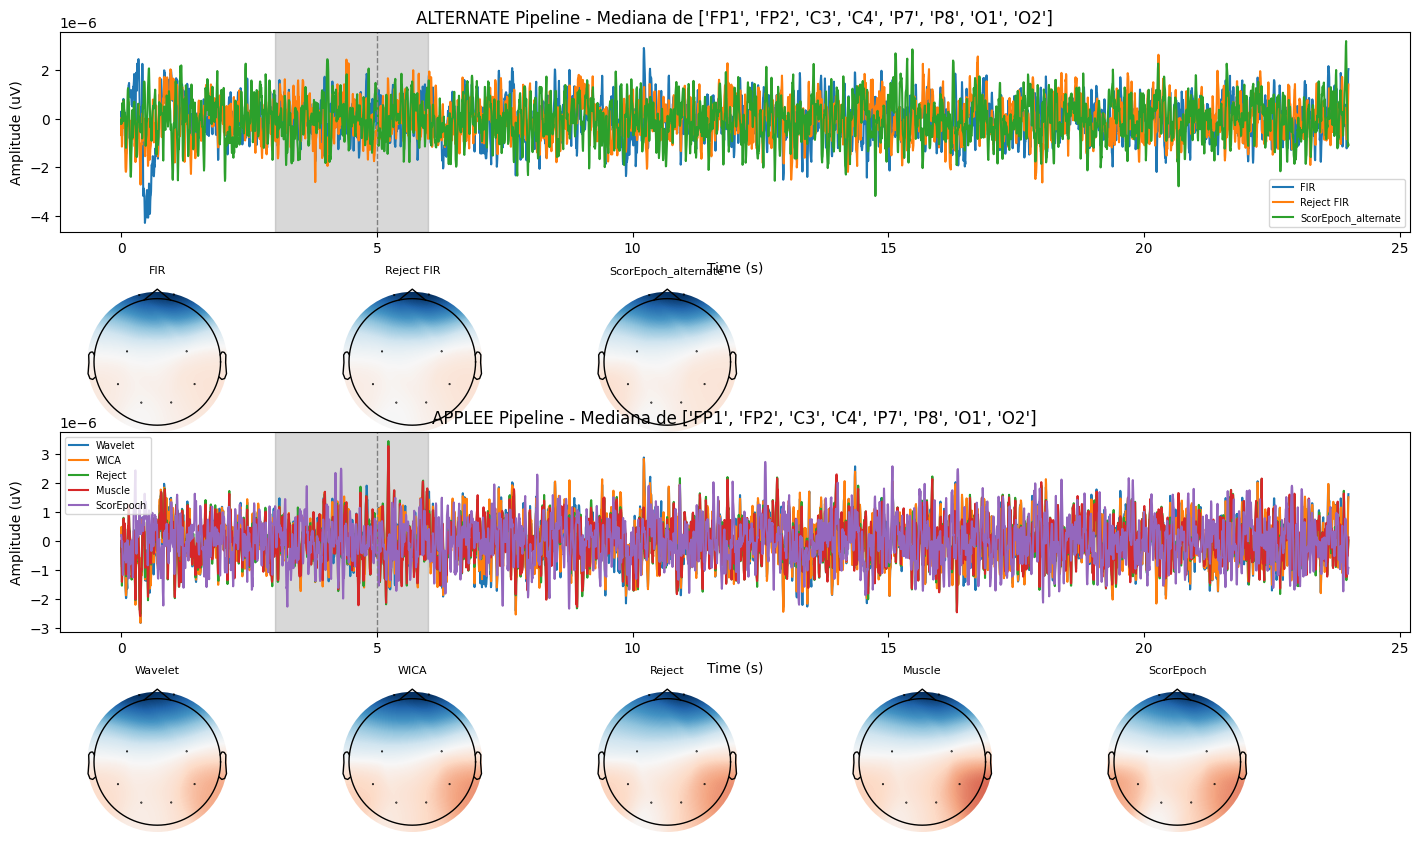

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob

channels_of_interest = ['FP1','FP2','C3', 'C4', 'P7', 'P8', 'O1', 'O2']

# Función para cargar y extraer mediana por etapa y sujeto

def process_pipeline(file_dicts):
    sfreq = 200  # Frecuencia de muestreo
    duration_samples = int(sfreq * 24)  # 20 segundos
    all_subjects = {}

    for pipeline_label, file_dict in file_dicts.items():
        stage_keys = list(file_dict[0].keys())
        stage_signals = {k: [] for k in stage_keys}
        stage_topos = {k: [] for k in stage_keys}

        for subj_files in file_dict:
            for stage, path in subj_files.items():
                raw = mne.io.read_raw_fif(path, preload=True)
                raw.pick(channels_of_interest)
                data, _ = raw.get_data(return_times=True)
                signal = np.median(data, axis=0)
                topo = np.median(data, axis=1)
                signal = signal[:duration_samples]  # recortar
                stage_signals[stage].append(signal)
                stage_topos[stage].append(topo)

        avg_pipeline = {}
        for stage in stage_keys:
            avg_pipeline[stage] = {
                'signal': np.mean(stage_signals[stage], axis=0),
                'topo': np.mean(stage_topos[stage], axis=0)
            }
        avg_pipeline['sfreq'] = sfreq
        all_subjects[pipeline_label] = avg_pipeline

    return all_subjects

# Buscar archivos de todos los sujetos
base_dir = r'F:\EEG_MULTICENTER\BIDS_MUSCA_OO'
subject_dirs = sorted(glob(os.path.join(base_dir, 'derivatives', 'APPLEE', 'sub-*')))

applee_files_all = []
alternate_files_all = []

for subj_dir in subject_dirs:
    subj_id = os.path.basename(subj_dir)
    eeg_dir_applee = os.path.join(subj_dir, 'ses-eeg', 'eeg')
    eeg_dir_alternate = eeg_dir_applee.replace('APPLEE', 'ALTERNATE_PIPELINE')

    applee_files_all.append({
        "Wavelet": os.path.join(eeg_dir_applee, f'{subj_id}_ses-eeg_task-rest_desc-wavelet_eeg.fif'),
        "WICA": os.path.join(eeg_dir_applee, f'{subj_id}_ses-eeg_task-rest_desc-wica_eeg.fif'),
        "Reject": os.path.join(eeg_dir_applee, f'{subj_id}_ses-eeg_task-rest_desc-reject_eeg.fif'),
        "Muscle": os.path.join(eeg_dir_applee, f'{subj_id}_ses-eeg_task-rest_desc-Muscle_sm0.7_ct0.2_fb0.05_eeg.fif'),
        "ScorEpoch": os.path.join(eeg_dir_applee, f'{subj_id}_ses-eeg_task-rest_desc-scorEpoch_24_eeg.fif'),
    })

    alternate_files_all.append({
        "FIR": os.path.join(eeg_dir_alternate, f'{subj_id}_ses-eeg_task-rest_desc-fir_eeg.fif'),
        "Reject FIR": os.path.join(eeg_dir_alternate, f'{subj_id}_ses-eeg_task-rest_desc-reject_fir_eeg.fif'),
        "ScorEpoch_alternate": os.path.join(eeg_dir_alternate, f'{subj_id}_ses-eeg_task-rest_desc-scorEpochFir_24_eeg.fif'),
    })

# Procesar todos los sujetos
data = process_pipeline({"APPLEE": applee_files_all, "ALTERNATE": alternate_files_all})

# Visualizar promedio por etapa como en la figura original

def plot_group_average_stages(data):
    sfreq = data['APPLEE']['sfreq']
    times = np.arange(int(sfreq * 24)) / sfreq

    fig = plt.figure(figsize=(15, 10))

    for idx, pipeline_label in enumerate(['ALTERNATE', 'APPLEE']):
        stages = [k for k in data[pipeline_label].keys() if k != 'sfreq']

        y_signal = 0.95 - 0.4 * idx
        ax_signal = plt.axes([0.1, y_signal, 0.9, 0.2])
        for stage in stages:
            ax_signal.plot(times, data[pipeline_label][stage]['signal'], label=stage)
        ax_signal.set_title(f'{pipeline_label} Pipeline ')
        ax_signal.set_xlabel('Time (s)')
        ax_signal.set_ylabel('Amplitude (uV)')
        ax_signal.axvspan(3, 6, color='gray', alpha=0.3)
        ax_signal.axvline(x=5, color='gray', linestyle='--', linewidth=1)
        ax_signal.legend(fontsize=7)

        y_topo = y_signal - 0.20
        for i, stage in enumerate(stages):
            ax = plt.axes([0.1 + i*0.17, y_topo, 0.13, 0.15])

            info = mne.create_info(ch_names=channels_of_interest, sfreq=sfreq, ch_types='eeg')
            info.set_montage('standard_1020',match_case=False)
            mne.viz.plot_topomap(data[pipeline_label][stage]['topo'], info, axes=ax, show=False, contours=0)
            ax.set_title(stage, fontsize=8)

    plt.savefig("group_average_all_pipelines.png", dpi=300)
    plt.savefig("group_average_all_pipelines.pdf")
    plt.show()

plot_group_average_stages(data)


Extracting parameters from F:\EEG_MULTICENTER\Polonia\sub-01\eeg\sub-01_task-rest_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 661519  =      0.000 ...   661.519 secs...
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 661 samples (3.305 s)

Opening raw data file F:\EEG_MULTICENTER\Polonia\derivatives\APPLEE\sub-01\eeg\sub-01_task-rest_desc-wavelet_eeg.fif...
Isotrak not found
    Range : 0 ... 131999 =      0.000 ...   659.995 secs
Ready.
Reading 0 ... 131999  =      0.000 ...   659.995 secs...

C:\Users\Luisa\AppData\Local\Temp\ipykernel_18524\3790549462.py:127: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_signal.legend(fontsize=7, loc='upper right')


NameError: name 'channels_of_interest' is not defined

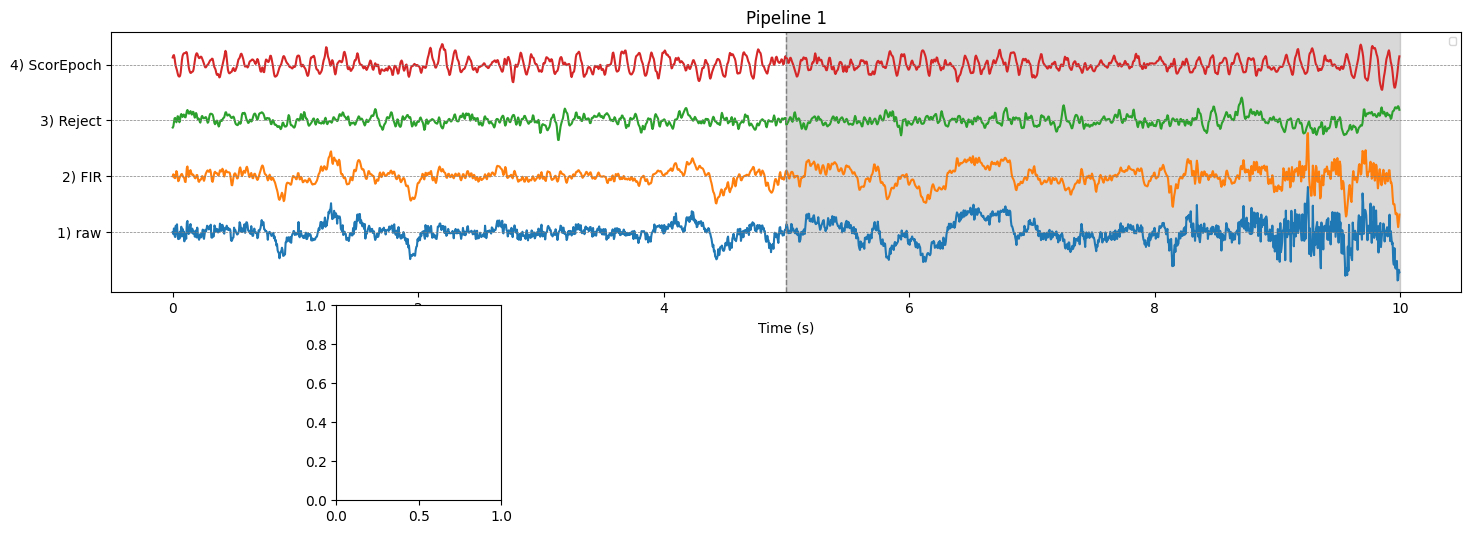

In [3]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob


# Función para cargar y extraer mediana por etapa y sujeto
def process_pipeline(file_dicts):
    sfreq = 200  # Frecuencia de muestreo
    duration_samples = int(sfreq * 10)  # 20 segundos
    all_subjects = {}

    for pipeline_label, file_dict in file_dicts.items():
        stage_keys = list(file_dict[0].keys())
        stage_signals = {k: [] for k in stage_keys}
        stage_topos = {k: [] for k in stage_keys}

        for subj_files in file_dict:
            for stage, path in subj_files.items():
                if path.endswith('.fif'):
                    channels_of_interest = ['FP1','FP2','C3', 'C4', 'P7', 'P8', 'O1', 'O2']
                    raw = mne.io.read_raw_fif(path, preload=True)
                elif path.endswith('.vhdr'):
                    channels_of_interest = ['Fp1','Fp2','C3', 'C4', 'P7', 'P8', 'O1', 'O2']
                    raw = mne.io.read_raw_brainvision(path, preload=True)
                    raw.resample(sfreq, npad='auto', verbose='error')
                    raw.filter(l_freq=1,  h_freq=None, picks=channels_of_interest)
                    raw.pick(channels_of_interest)
                    data, _ = raw.get_data(return_times=True)
                    from scipy.signal import detrend
                    data = detrend(data, axis=1, type='linear')
                else:
                    print(f"[SKIP] Formato no soportado: {path}")
                    continue

                if not path.endswith('.vhdr'):  # para los fif
                    raw.pick(channels_of_interest)
                    data, _ = raw.get_data(return_times=True)

                signal = np.median(data, axis=0)
                topo = np.median(data, axis=1)
                signal = signal[:duration_samples]

                stage_signals[stage].append(signal)
                stage_topos[stage].append(topo)

        avg_pipeline = {}
        for stage in stage_keys:
            avg_pipeline[stage] = {
                'signal': np.mean(stage_signals[stage], axis=0),
                'topo': np.mean(stage_topos[stage], axis=0)
            }
        avg_pipeline['sfreq'] = sfreq
        all_subjects[pipeline_label] = avg_pipeline

    return all_subjects

# Buscar archivos de todos los sujetos
base_dir = r'F:\EEG_MULTICENTER\Polonia'
subject_dirs = sorted(glob(os.path.join(base_dir, 'derivatives', 'APPLEE', 'sub-*')))

applee_files_all = []
alternate_files_all = []

for subj_dir in subject_dirs:
    subj_id = os.path.basename(subj_dir)
    eeg_dir_applee = os.path.join(subj_dir, 'eeg')
    eeg_dir_alternate = eeg_dir_applee.replace('APPLEE', 'ALTERNATE_PIPELINE')
    applee_files_all.append({
        "1) raw": os.path.join(base_dir, subj_id,'eeg',f'{subj_id}_task-rest_eeg.vhdr'),
        "2) Wavelet": os.path.join(eeg_dir_applee, f'{subj_id}_task-rest_desc-wavelet_eeg.fif'),
        "3) WICA": os.path.join(eeg_dir_applee, f'{subj_id}_task-rest_desc-wica_eeg.fif'),
        "4) Reject": os.path.join(eeg_dir_applee, f'{subj_id}_task-rest_desc-reject_eeg.fif'),
        "5) Muscle IC": os.path.join(eeg_dir_applee, f'{subj_id}_task-rest_desc-Muscle_sm0.7_ct0.2_fb0.05_eeg.fif'),
        "6) ScorEpoch": os.path.join(eeg_dir_applee, f'{subj_id}_task-rest_desc-scorEpoch_24_eeg.fif'),
    })

    alternate_files_all.append({
        "1) raw": os.path.join(base_dir, subj_id,'eeg',f'{subj_id}_task-rest_eeg.vhdr'),
        "2) FIR": os.path.join(eeg_dir_alternate, f'{subj_id}_task-rest_desc-fir_eeg.fif'),
        "3) Reject": os.path.join(eeg_dir_alternate, f'{subj_id}_task-rest_desc-reject_fir_eeg.fif'),
        "4) ScorEpoch": os.path.join(eeg_dir_alternate, f'{subj_id}_task-rest_desc-scorEpochFir_24_eeg.fif'),
    })

# Procesar todos los sujetos
data = process_pipeline({"Pipeline 2 - APPLEE": applee_files_all, "Pipeline 1": alternate_files_all})

def plot_group_average_stages(data):
    sfreq = data['Pipeline 2 - APPLEE']['sfreq']
    times = np.arange(int(sfreq * 10)) / sfreq

    # Calcular offset dinámico basado en amplitud real
    all_signals = []
    for p in ['Pipeline 1', 'Pipeline 2 - APPLEE']:
        for stage in data[p]:
            if stage != 'sfreq':
                all_signals.append(data[p][stage]['signal'])
    global_max_amp = np.max(np.abs(all_signals))
    offset_step = global_max_amp * 1.1 # puedes ajustar este factor

    fig = plt.figure(figsize=(15, 13))

    for idx, pipeline_label in enumerate(['Pipeline 1', 'Pipeline 2 - APPLEE']):
        stages = [k for k in data[pipeline_label].keys() if k != 'sfreq']

        y_signal = 0.93 - 0.4 * idx
        ax_signal = plt.axes([0.1, y_signal, 0.9, 0.2])
   
        offsets = []
        labels = []
        for i, stage in enumerate(stages):
            offset = i * offset_step
            ax_signal.plot(times, data[pipeline_label][stage]['signal'] + offset)
            ax_signal.axhline(offset, color='gray', linestyle='--', linewidth=0.5)
            offsets.append(offset)
            labels.append(stage)

        ax_signal.set_yticks(offsets)
        ax_signal.set_yticklabels(labels)


        ax_signal.set_title(f'{pipeline_label}')
        ax_signal.set_xlabel('Time (s)')
        ax_signal.axvspan(5, 10, color='gray', alpha=0.3)
        ax_signal.axvline(x=5, color='gray', linestyle='--', linewidth=1)
        ax_signal.legend(fontsize=7, loc='upper right')

        y_signal = 0.94 - 0.4 * idx  # idx es 0 o 1, según el pipeline
        y_topo = y_signal - 0.17
        n_stages = len(stages)
        topo_width = 0.11
        total_width = n_stages * topo_width + (n_stages - 1) * 0.02  # espacio incluido
        start_x = 0.5 - total_width / 2  # centrar

        for i, stage in enumerate(stages):
            x_pos = start_x + i * (topo_width + 0.02)
            ax = plt.axes([x_pos, y_topo, topo_width, 0.15])
            info = mne.create_info(ch_names=channels_of_interest, sfreq=sfreq, ch_types='eeg')
            info.set_montage('standard_1020', match_case=False)
            im, _ = mne.viz.plot_topomap(data[pipeline_label][stage]['topo'], info, axes=ax, show=False, contours=0)
            ax.set_title(stage, fontsize=8)
        # Colorbar vertical común para cada pipeline
        cbar_ax = fig.add_axes([0.93, y_topo, 0.015, 0.15])
        cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
        cbar.set_label('Channel Median (uV)')

    plt.savefig("group_average_all_pipelines.pdf", dpi=300, bbox_inches='tight')

    plt.show()

# Ejecutar la visualización
plot_group_average_stages(data)


Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 661 samples (3.305 s)

Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.0

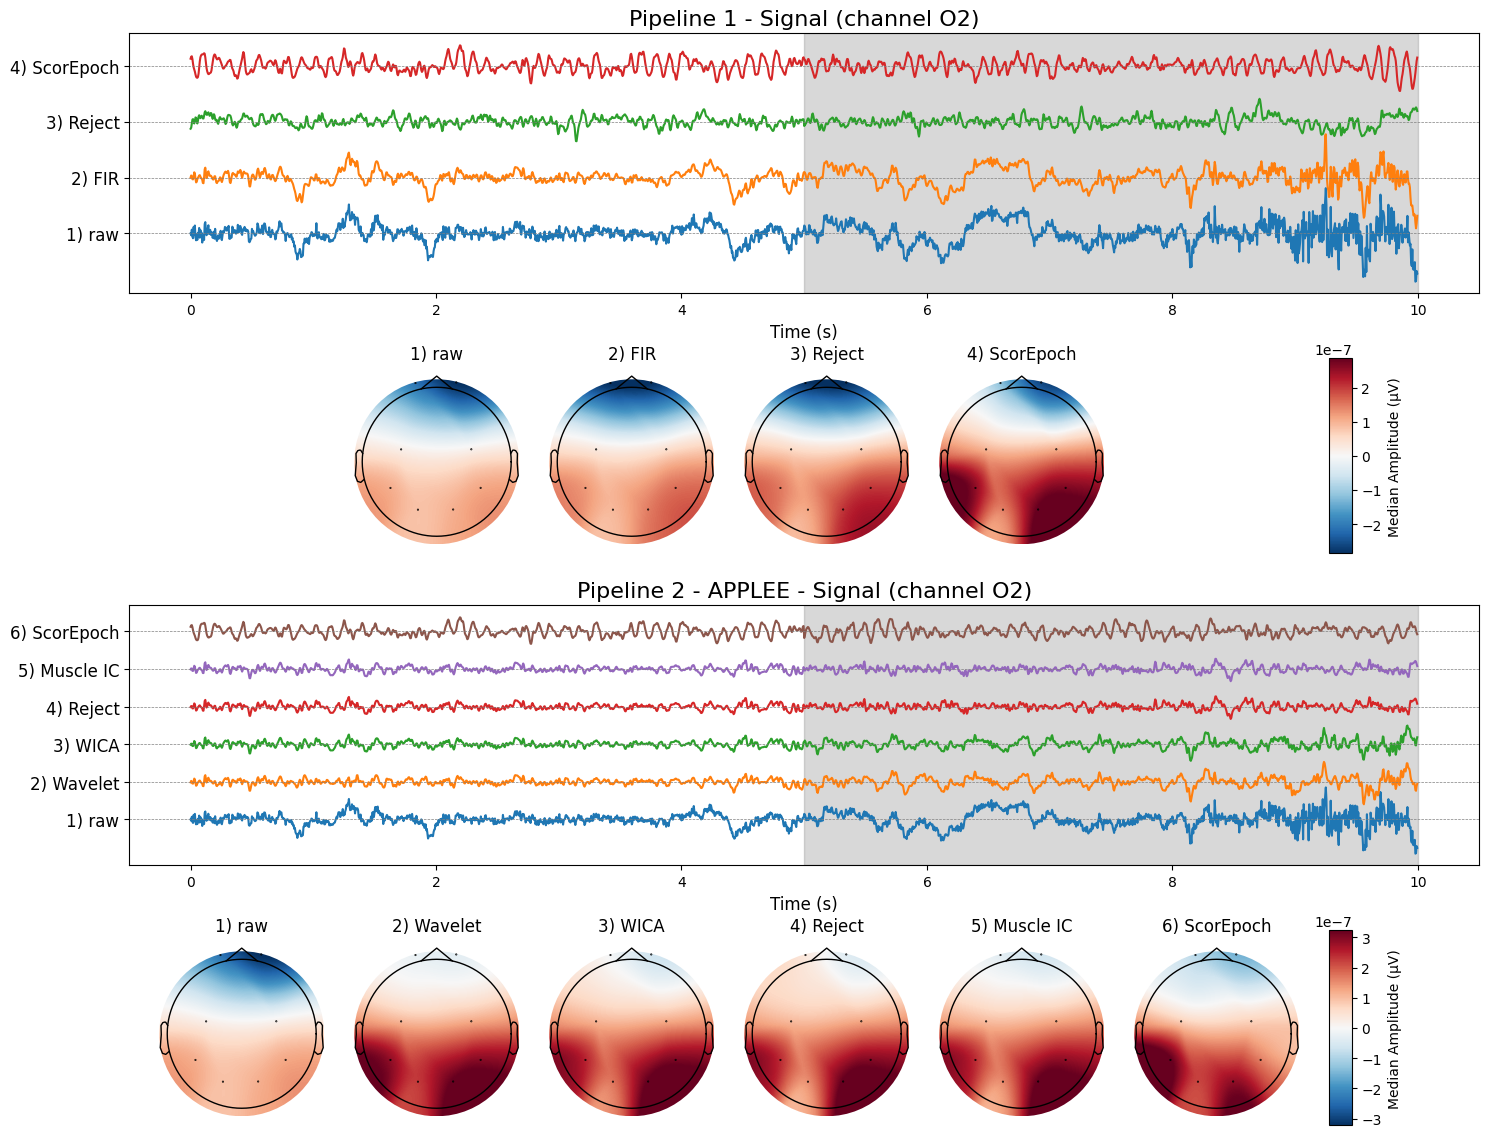

In [16]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import os

# --- INPUT: Cambia aquí la ruta del sujeto específico ---
subject_id = 'sub-01'
pipeline_dir_1 = fr'F:\EEG_MULTICENTER\Polonia\derivatives\ALTERNATE_PIPELINE\{subject_id}\eeg'
pipeline_dir_2 = fr'F:\EEG_MULTICENTER\Polonia\derivatives\APPLEE\{subject_id}\eeg'
vhdr_file = fr'F:\EEG_MULTICENTER\Polonia\{subject_id}\eeg\{subject_id}_task-rest_eeg.vhdr'

# Diccionarios con rutas por etapa
file_dict = {
    "Pipeline 1": {
        "1) raw": vhdr_file,
        "2) FIR": os.path.join(pipeline_dir_1, f'{subject_id}_task-rest_desc-fir_eeg.fif'),
        "3) Reject": os.path.join(pipeline_dir_1, f'{subject_id}_task-rest_desc-reject_fir_eeg.fif'),
        "4) ScorEpoch": os.path.join(pipeline_dir_1, f'{subject_id}_task-rest_desc-scorEpochFir_24_eeg.fif'),
    },
    "Pipeline 2 - APPLEE": {
        "1) raw": vhdr_file,
        "2) Wavelet": os.path.join(pipeline_dir_2, f'{subject_id}_task-rest_desc-wavelet_eeg.fif'),
        "3) WICA": os.path.join(pipeline_dir_2, f'{subject_id}_task-rest_desc-wica_eeg.fif'),
        "4) Reject": os.path.join(pipeline_dir_2, f'{subject_id}_task-rest_desc-reject_eeg.fif'),
        "5) Muscle IC": os.path.join(pipeline_dir_2, f'{subject_id}_task-rest_desc-Muscle_sm0.7_ct0.2_fb0.05_eeg.fif'),
        "6) ScorEpoch": os.path.join(pipeline_dir_2, f'{subject_id}_task-rest_desc-scorEpoch_24_eeg.fif'),
    }
}

def process_single_subject(file_dict):
    sfreq = 200
    duration_samples = int(sfreq * 10)
    channels_all_vhdr = ['Fp1', 'Fp2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2']
    channels_all_fif  = ['FP1', 'FP2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2']
    ch_signal = 'O2'

    ch_signal = 'O2'  # canal para la serie temporal
    results = {}

    for pipeline_label, stages in file_dict.items():
        signals = {}
        topos = {}
        for stage, path in stages.items():
            if path.endswith('.fif'):
                raw = mne.io.read_raw_fif(path, preload=True, verbose='error')
                raw.pick(channels_all_fif)
                channels_all = channels_all_fif
            elif path.endswith('.vhdr'):
                raw = mne.io.read_raw_brainvision(path, preload=True, verbose='error')
                raw.resample(sfreq, npad='auto')
                raw.filter(1, None, picks=channels_all_vhdr)
                raw.pick(channels_all_vhdr)
                channels_all = channels_all_vhdr
                from scipy.signal import detrend
                raw._data = detrend(raw._data, axis=1, type='linear')
            else:
                continue

            data = raw.get_data()
            topo = np.median(data, axis=1)
            signal = data[channels_all.index(ch_signal), :duration_samples]

            signals[stage] = signal
            topos[stage] = topo

        results[pipeline_label] = {'signals': signals, 'topos': topos, 'sfreq': sfreq}

    return results


def plot_subject_stages(data):
    sfreq = list(data.values())[0]['sfreq']
    times = np.arange(int(sfreq * 10)) / sfreq
    ch_names = ['FP1', 'FP2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2']

    fig = plt.figure(figsize=(15, 13))

    for idx, (pipeline_label, content) in enumerate(data.items()):
        stages = list(content['signals'].keys())

        y_signal = 0.93 - 0.44 * idx
        ax_signal = plt.axes([0.1, y_signal, 0.9, 0.2])
        offset_step = np.max([np.max(np.abs(sig)) for sig in content['signals'].values()]) * 1.1

        offsets = []
        for i, stage in enumerate(stages):
            offset = i * offset_step
            ax_signal.plot(times, content['signals'][stage] + offset)
            ax_signal.axhline(offset, color='gray', linestyle='--', linewidth=0.5)
            offsets.append(offset)

        ax_signal.set_yticks(offsets)
        ax_signal.set_yticklabels(stages, fontsize=12)
        ax_signal.set_title(f'{pipeline_label} - Signal (channel O2)', fontsize=16)
        ax_signal.set_xlabel('Time (s)', fontsize=12)
        ax_signal.axvspan(5, 10, color='gray', alpha=0.3)

        y_topo = y_signal - 0.20
        topo_width = 0.11
        total_width = len(stages) * topo_width + (len(stages) - 1) * 0.02
        start_x = 0.5 - total_width / 2

        for i, stage in enumerate(stages):
            x_pos = start_x + i * (topo_width + 0.02)
            ax = plt.axes([x_pos, y_topo, topo_width, 0.15])
            info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
            info.set_montage('standard_1020', match_case=False)
            im, _ = mne.viz.plot_topomap(content['topos'][stage], info, axes=ax, show=False, contours=0)
            ax.set_title(stage, fontsize=12)

        # Colorbar común
        cbar_ax = fig.add_axes([0.90, y_topo, 0.015, 0.15])
        fig.colorbar(im, cax=cbar_ax, orientation='vertical').set_label('Median Amplitude (µV)')

    plt.savefig(f"group_average_{subject_id}.pdf", dpi=300, bbox_inches='tight')
    plt.show()


# Ejecutar
results = process_single_subject(file_dict)
plot_subject_stages(results)

Opening raw data file F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-wavelet_eeg.fif...
Isotrak not found
    Range : 0 ... 60999 =      0.000 ...   304.995 secs
Ready.
Reading 0 ... 60999  =      0.000 ...   304.995 secs...
Opening raw data file F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-wica_eeg.fif...
Isotrak not found
    Range : 0 ... 60999 =      0.000 ...   304.995 secs
Ready.
Reading 0 ... 60999  =      0.000 ...   304.995 secs...
Opening raw data file F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-reject_eeg.fif...
Isotrak not found
    Range : 0 ... 46999 =      0.000 ...   234.995 secs
Ready.
Reading 0 ... 46999  =      0.000 ...   234.995 secs...
Opening raw data file F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses

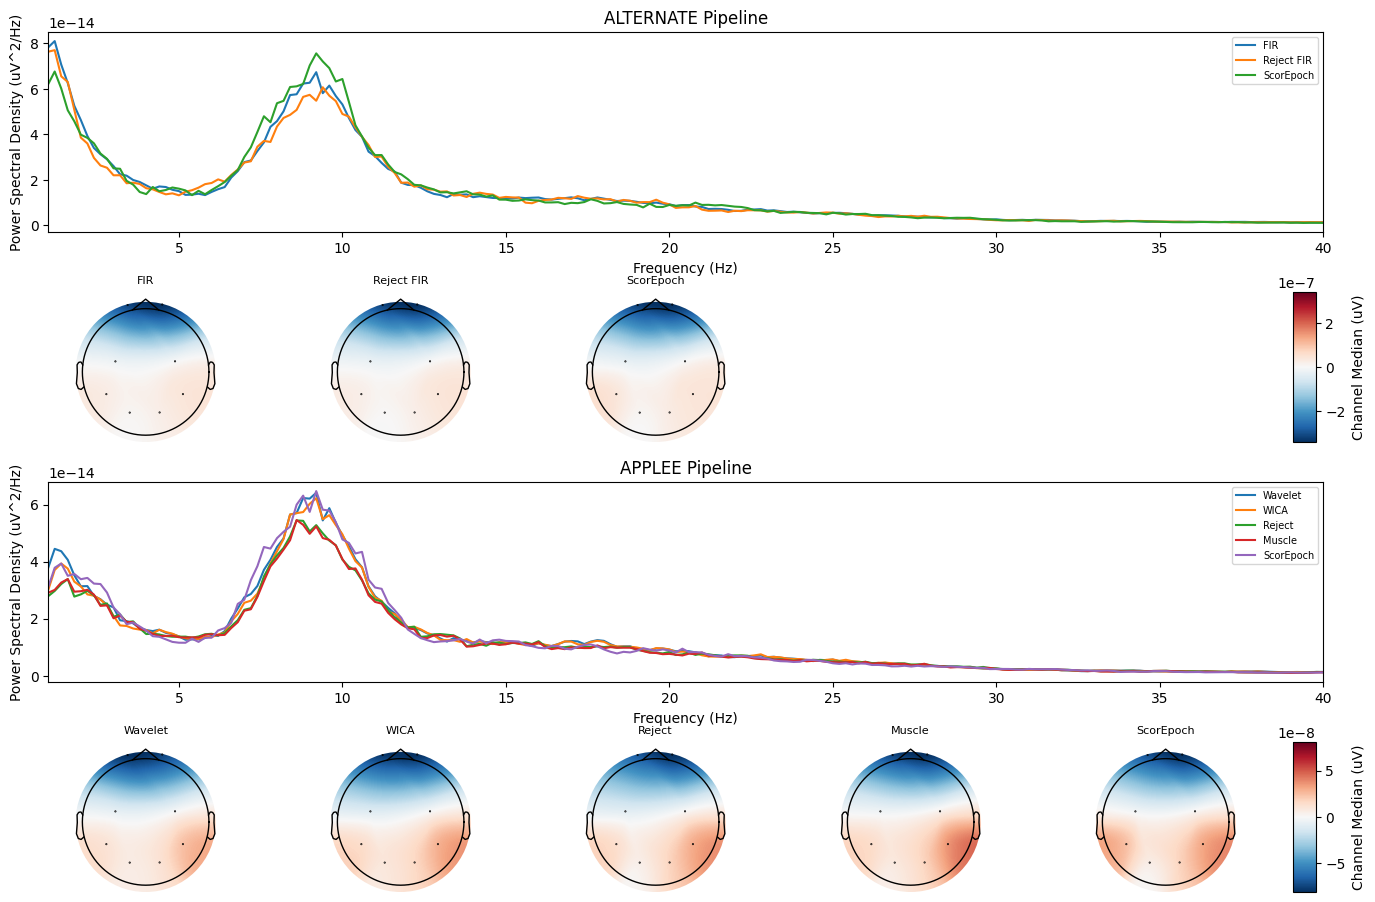

In [192]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob

channels_of_interest = ['FP1','FP2','C3', 'C4', 'P7', 'P8', 'O1', 'O2']

# Función para cargar y extraer mediana por etapa y sujeto
def process_pipeline(file_dicts):
    sfreq = 200  # Frecuencia de muestreo
    all_subjects = {}

    for pipeline_label, file_dict in file_dicts.items():
        stage_keys = list(file_dict[0].keys())
        stage_signals = {k: [] for k in stage_keys}
        stage_topos = {k: [] for k in stage_keys}

        for subj_files in file_dict:
            for stage, path in subj_files.items():
                raw = mne.io.read_raw_fif(path, preload=True)
                raw.pick(channels_of_interest)
                data, _ = raw.get_data(return_times=True)
                signal = np.median(data, axis=0)
                topo = np.median(data, axis=1)
                stage_signals[stage].append(signal)
                stage_topos[stage].append(topo)

        avg_pipeline = {}
        for stage in stage_keys:
            min_len = min([s.shape[0] for s in stage_signals[stage]])
            stage_signals_trimmed = [s[:min_len] for s in stage_signals[stage]]
            stage_topos_trimmed = [t for t in stage_topos[stage]]
            avg_pipeline[stage] = {
                'signal': np.mean(np.stack(stage_signals_trimmed, axis=0), axis=0),
                'topo': np.mean(np.stack(stage_topos_trimmed, axis=0), axis=0)
            }
        avg_pipeline['sfreq'] = sfreq
        all_subjects[pipeline_label] = avg_pipeline

    return all_subjects

# Buscar archivos de todos los sujetos
base_dir = r'F:\EEG_MULTICENTER\BIDS_MUSCA_OO'
subject_dirs = sorted(glob(os.path.join(base_dir, 'derivatives', 'APPLEE', 'sub-*')))

applee_files_all = []
alternate_files_all = []

for subj_dir in subject_dirs:
    subj_id = os.path.basename(subj_dir)
    eeg_dir_applee = os.path.join(subj_dir, 'ses-eeg', 'eeg')
    eeg_dir_alternate = eeg_dir_applee.replace('APPLEE', 'ALTERNATE_PIPELINE')

    applee_files_all.append({
        "Wavelet": os.path.join(eeg_dir_applee, f'{subj_id}_ses-eeg_task-rest_desc-wavelet_eeg.fif'),
        "WICA": os.path.join(eeg_dir_applee, f'{subj_id}_ses-eeg_task-rest_desc-wica_eeg.fif'),
        "Reject": os.path.join(eeg_dir_applee, f'{subj_id}_ses-eeg_task-rest_desc-reject_eeg.fif'),
        "Muscle": os.path.join(eeg_dir_applee, f'{subj_id}_ses-eeg_task-rest_desc-Muscle_sm0.7_ct0.2_fb0.05_eeg.fif'),
        "ScorEpoch": os.path.join(eeg_dir_applee, f'{subj_id}_ses-eeg_task-rest_desc-scorEpoch_24_eeg.fif'),
    })

    alternate_files_all.append({
        "FIR": os.path.join(eeg_dir_alternate, f'{subj_id}_ses-eeg_task-rest_desc-fir_eeg.fif'),
        "Reject FIR": os.path.join(eeg_dir_alternate, f'{subj_id}_ses-eeg_task-rest_desc-reject_fir_eeg.fif'),
        "ScorEpoch": os.path.join(eeg_dir_alternate, f'{subj_id}_ses-eeg_task-rest_desc-scorEpochFir_24_eeg.fif'),
    })

# Procesar todos los sujetos
data = process_pipeline({"APPLEE": applee_files_all, "ALTERNATE": alternate_files_all})

# Visualizar promedio por etapa como en la figura original
def plot_group_average_stages(data):
    sfreq = data['APPLEE']['sfreq']
    fig = plt.figure(figsize=(15, 10))

    for idx, pipeline_label in enumerate(['ALTERNATE', 'APPLEE']):
        stages = [k for k in data[pipeline_label].keys() if k != 'sfreq']

        y_psd = 0.9- 0.45 * idx
        ax_psd = plt.axes([0.1, y_psd, 0.85, 0.2])

        
        for stage in stages:
            info = mne.create_info(ch_names=channels_of_interest, sfreq=sfreq, ch_types='eeg')
            temp_data = np.tile(data[pipeline_label][stage]['signal'], (len(channels_of_interest), 1))
            raw_temp = mne.io.RawArray(temp_data, info)

            epoch_len = int(sfreq * 5)
            signal_data = raw_temp.get_data()
            n_epochs = signal_data.shape[1] // epoch_len
            data_epochs = [signal_data[:, i*epoch_len:(i+1)*epoch_len] for i in range(n_epochs)]
            data_epochs = np.array(data_epochs)

            psd_list = []
            for ch in range(data_epochs.shape[1]):
                psd, freqs = mne.time_frequency.psd_array_multitaper(
                    data_epochs[:, ch, :], sfreq=sfreq, fmin=1, fmax=40,
                    adaptive=True, normalization='full', verbose=False
                )
                psd_list.append(np.median(psd, axis=0))

            mean_psd = np.mean(psd_list, axis=0)
            ax_psd.plot(freqs, mean_psd, label=stage)


        ax_psd.set_title(f'{pipeline_label} Pipeline')
        ax_psd.set_xlabel('Frequency (Hz)')
        ax_psd.set_ylabel('Power Spectral Density (uV^2/Hz)')
        ax_psd.set_xlim(1, 40)
        ax_psd.legend(fontsize=7)

        y_topo = y_psd - 0.21
        for i, stage in enumerate(stages):
            ax = plt.axes([0.1 + i*0.17, y_topo, 0.13, 0.15])
            info = mne.create_info(ch_names=channels_of_interest, sfreq=sfreq, ch_types='eeg')
            info.set_montage('standard_1020',match_case=False)
            im, _ = mne.viz.plot_topomap(data[pipeline_label][stage]['topo'], info, axes=ax, show=False, contours=0)
            ax.set_title(stage, fontsize=8)
        # Colorbar vertical común para cada pipeline
        cbar_ax = fig.add_axes([0.93, y_topo, 0.015, 0.15])
        cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
        cbar.set_label('Channel Median (uV)')


    plt.savefig("group_average_psd_all_pipelines.png", dpi=300)
    plt.savefig("group_average_psd_all_pipelines.pdf")
    plt.show()

plot_group_average_stages(data)


In [ ]:
#Pipeline APPLEE
Wavelet = mne.io.read_raw(r'F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-wavelet_eeg.fif')
Wica = mne.io.read_raw(r"F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-wica_eeg.fif")
reject = mne.io.read_raw(r"F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-reject_eeg.fif")
muscle  = mne.io.read_raw(r"F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-Muscle_sm0.7_ct0.2_fb0.05_eeg.fif")
scorEpochs  = mne.io.read_raw(r"F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-scorEpoch_24_eeg.fif")

# Pipeline ALTERNATE
fir = mne.io.read_raw(r"F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\ALTERNATE_PIPELINE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-fir_eeg.fif")
reject_pipeline1 = mne.io.read_raw(r"F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\ALTERNATE_PIPELINE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-reject_fir_eeg.fif")
scorEpochs_pipeline1 = mne.io.read_raw(r"F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\ALTERNATE_PIPELINE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-scorEpochFir_24_eeg.fif")

Opening raw data file F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-wavelet_eeg.fif...
Isotrak not found
    Range : 0 ... 60999 =      0.000 ...   304.995 secs
Ready.
Opening raw data file F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-wica_eeg.fif...
Isotrak not found
    Range : 0 ... 60999 =      0.000 ...   304.995 secs
Ready.
Opening raw data file F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-reject_eeg.fif...
Isotrak not found
    Range : 0 ... 46999 =      0.000 ...   234.995 secs
Ready.
Opening raw data file F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-Muscle_sm0.7_ct0.2_fb0.05_eeg.fif...
    Range : 0 ... 46999 =      0.000 ...   234.995 secs
Ready.
Opening raw data file F:\EEG_MULTICENTER\BIDS_MU

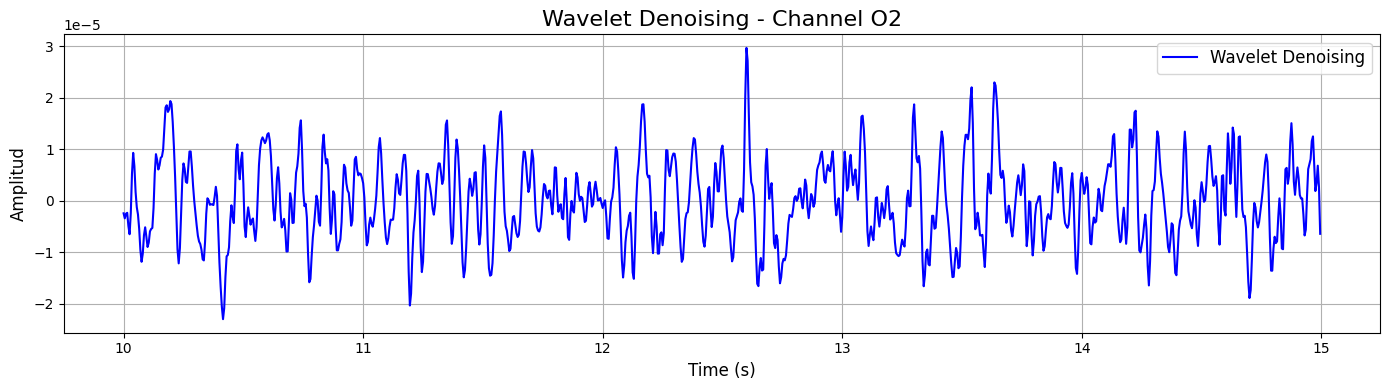

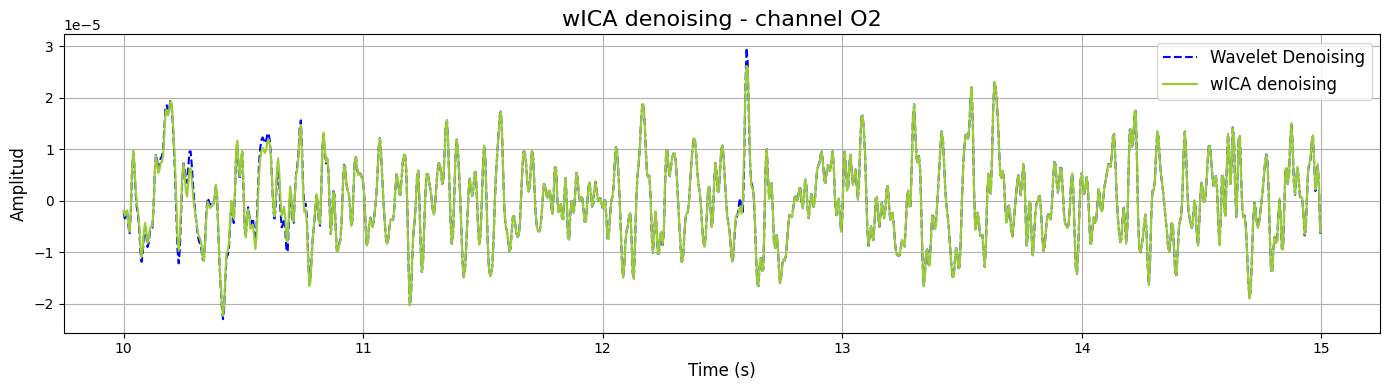

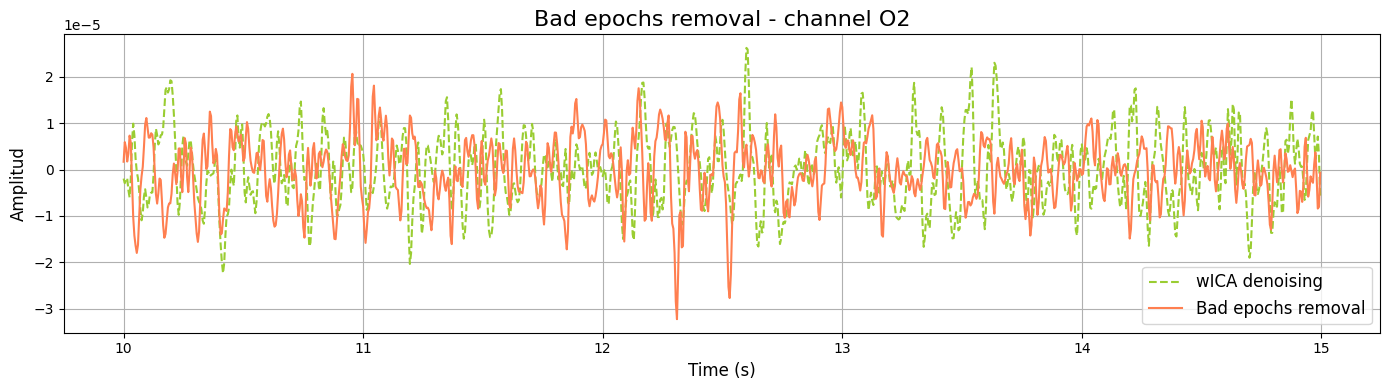

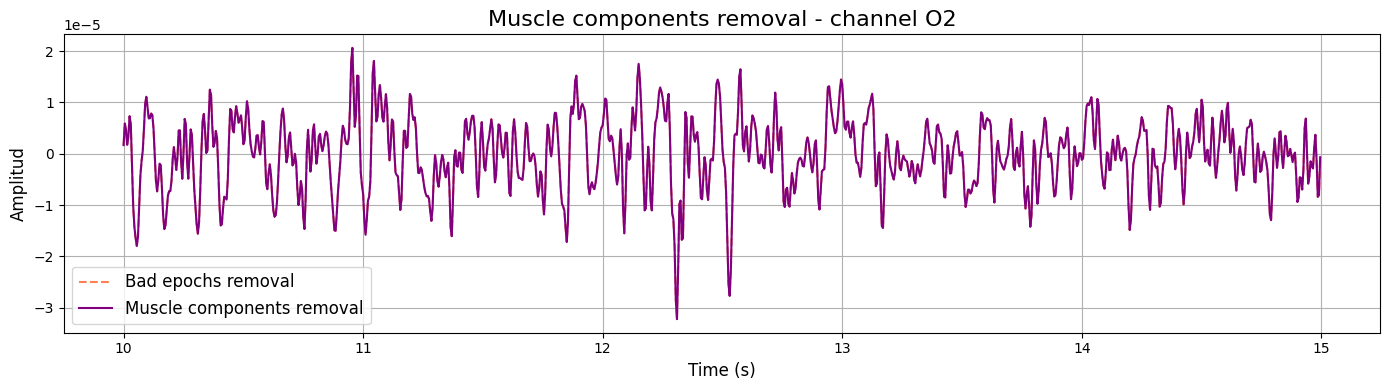

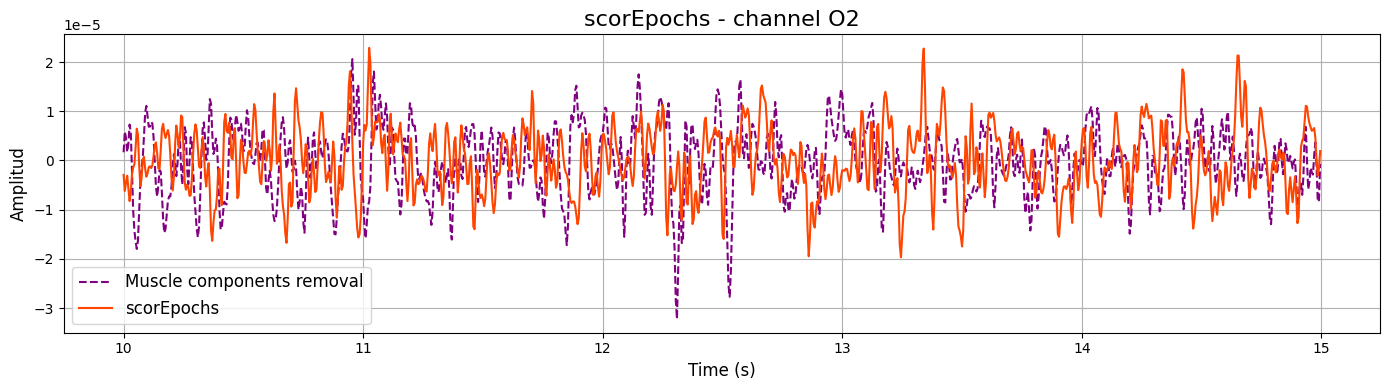

In [3]:
import matplotlib.pyplot as plt

# Lista de objetos Raw y sus etiquetas correspondientes
raws   = [Wavelet, Wica, reject, muscle, scorEpochs]
etapas = ["Wavelet Denoising", "wICA denoising", "Bad epochs removal", "Muscle components removal", "scorEpochs"]
colors = ['blue', 'yellowgreen', 'coral', 'purple', 'orangered']

channel   = "O2"
sfreq     = Wavelet.info['sfreq']   # Se asume que la frecuencia es la misma en todos los objetos
n_samples = int(sfreq * 5)         # Número de muestras correspondientes a 10 segundos

# Cambiamos el estilo a 'default' para evitar el fondo gris
plt.style.use('default')

# Iterar sobre cada etapa para generar gráficos independientes
for i in range(len(raws)):
    plt.figure(figsize=(14, 4))
    
    if i == 0:
        # Primer gráfico: solo se grafica la etapa Wavelet Denoising (línea continua)
        try:
            ch_idx = raws[i].ch_names.index(channel)
        except ValueError:
            plt.text(0.5, 0.5, f"Canal '{channel}' no encontrado en {etapas[i]}",
                     transform=plt.gca().transAxes, ha='center', fontsize=12)
            plt.show()
            continue
        
        data, times = raws[i].get_data(picks=[ch_idx], return_times=True)
        data_10s  = data[0, n_samples*2 : n_samples*3]
        times_10s = times[n_samples*2 : n_samples*3]
        
        plt.plot(times_10s, data_10s, color=colors[i],
                 linestyle='-', linewidth=1.5, label=etapas[i])
        plt.title(f"{etapas[i]} - Channel {channel}", fontsize=16)
    
    else:
        # Para las siguientes etapas: se grafican dos curvas:
        #   1. La etapa anterior en línea punteada.
        try:
            ch_idx_prev = raws[i-1].ch_names.index(channel)
            data_prev, times_prev = raws[i-1].get_data(picks=[ch_idx_prev], return_times=True)
            data_prev_10s  = data_prev[0, n_samples*2 : n_samples*3]
            times_prev_10s = times_prev[n_samples*2 : n_samples*3]
            plt.plot(times_prev_10s, data_prev_10s, color=colors[i-1],
                     linestyle='--', linewidth=1.5, label=etapas[i-1])
        except ValueError:
            plt.text(0.5, 0.7, f"Canal '{channel}' no encontrado en {etapas[i-1]}",
                     transform=plt.gca().transAxes, ha='center', fontsize=12)
        
        #   2. La etapa actual en línea continua.
        try:
            ch_idx = raws[i].ch_names.index(channel)
            data, times = raws[i].get_data(picks=[ch_idx], return_times=True)
            data_10s  = data[0, n_samples*2 : n_samples*3]
            times_10s = times[n_samples*2 : n_samples*3]
            plt.plot(times_10s, data_10s, color=colors[i],
                     linestyle='-', linewidth=1.5, label=etapas[i])
        except ValueError:
            plt.text(0.5, 0.3, f"Canal '{channel}' no encontrado en {etapas[i]}",
                     transform=plt.gca().transAxes, ha='center', fontsize=12)
        
        plt.title(f"{etapas[i]} - channel O2", fontsize=16)
    
    plt.xlabel("Time (s)", fontsize=12)
    plt.ylabel("Amplitud", fontsize=12)
    plt.grid(True)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 10.240 (s)
Plotting power spectral density (dB=True).
Figure(1000x350)
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 10.240 (s)
Plotting power spectral density (dB=True).


C:\Users\Luisa\AppData\Local\Temp\ipykernel_8796\1167645686.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  print(scorEpochs_pipeline1.plot_psd(picks=['FP1','FP2','C3','C4','P7','P8'], fmax= 45, show=True))
d:\flujo_portables\env_portables\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
d:\flujo_portables\env_portables\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


Figure(1000x350)


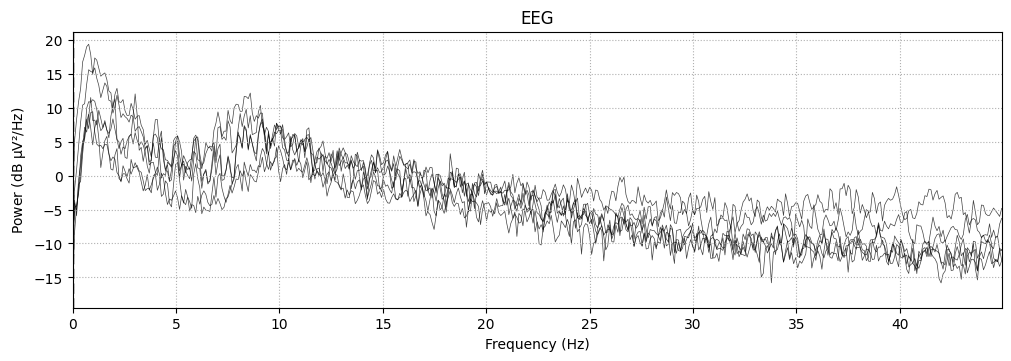

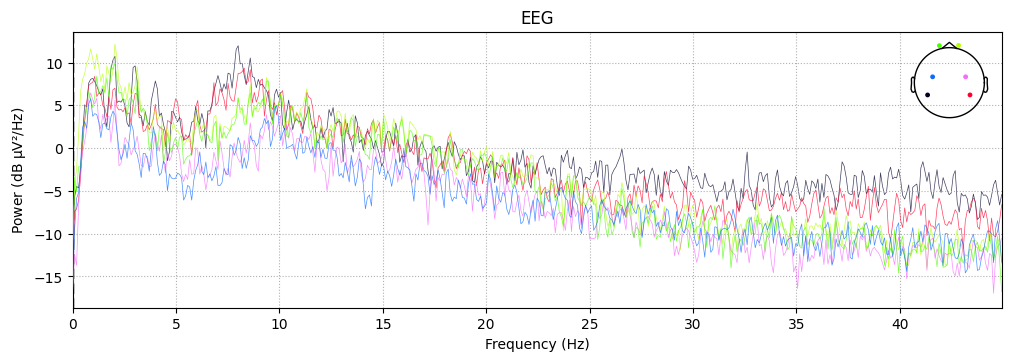

In [14]:
print(scorEpochs_pipeline1.plot_psd(picks=['FP1','FP2','C3','C4','P7','P8'], fmax= 45, show=True))
print(scorEpochs.plot_psd(picks=['FP1','FP2','C3','C4','P7','P8'], fmax= 45,show=True))